# 📐 Modelos Lineales Generalizados y Regularización (Lasso, Ridge y ElasticNet)

### Autor: Néstor León | Business Intelligence & Analytics
---

Cuando ajustamos una regresión lineal o logística con muchas variables, es muy fácil caer en el **sobreajuste (overfitting)** o encontrarnos con que variables muy correlacionadas entre sí hacen que los coeficientes oscilen de forma inestable (*multicolinealidad*).

La solución matemática son las técnicas de **regularización**: añadir una penalización a la función de coste por la magnitud de los coeficientes:
- **Ridge (Penalización L2, $\lambda \sum \beta_j^2$)**: Encoge los coeficientes hacia cero de forma proporcional, controlando la varianza pero manteniendo todas las variables.
- **Lasso (Penalización L1, $\lambda \sum |\beta_j|$)**: Hace que los coeficientes de las variables irrelevantes sean exactamente cero, realizando **selección automática de variables**.
- **ElasticNet**: Combina lo mejor de L1 y L2 ponderado por un factor $\alpha$ y $l1\_ratio$.

En este notebook calibramos estos modelos y visualizamos las trayectorias de los coeficientes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

print("Módulos de regularización GLM cargados.")


Módulos de regularización GLM cargados.


## 1. Simulación de un Escenario con Alta Multicolinealidad

Generamos un problema con 20 variables predictoras, donde muchas son combinaciones lineales ruidosas de unas pocas variables raíz (situación muy común en bases de datos de clientes y finanzas).


In [2]:
np.random.seed(42)
n_samples = 300
n_features = 20

X_raw = np.random.randn(n_samples, n_features)

# Generamos multicolinealidad forzada: las variables 5 a 10 son copias ruidosas de las primeras 4
for i in range(5, 12):
    X_raw[:, i] = X_raw[:, i % 4] * 0.8 + np.random.normal(0, 0.2, n_samples)

# Definimos una señal real dependiente únicamente de 4 variables verdaderas
beta_real = np.zeros(n_features)
beta_real[0] = 4.5
beta_real[1] = -3.2
beta_real[2] = 2.0
beta_real[3] = -1.5

y = np.dot(X_raw, beta_real) + np.random.normal(0, 1.5, n_samples)

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.25, random_state=42)

# La regularización requiere SIEMPRE variables estandarizadas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset generado: {n_samples} observaciones con {n_features} características.")


Dataset generado: 300 observaciones con 20 características.


## 2. Trayectoria de Regularización en Lasso y Ridge

Observamos cómo evolucionan los coeficientes a medida que aumentamos la intensidad de penalización $\alpha$ (o $\lambda$).


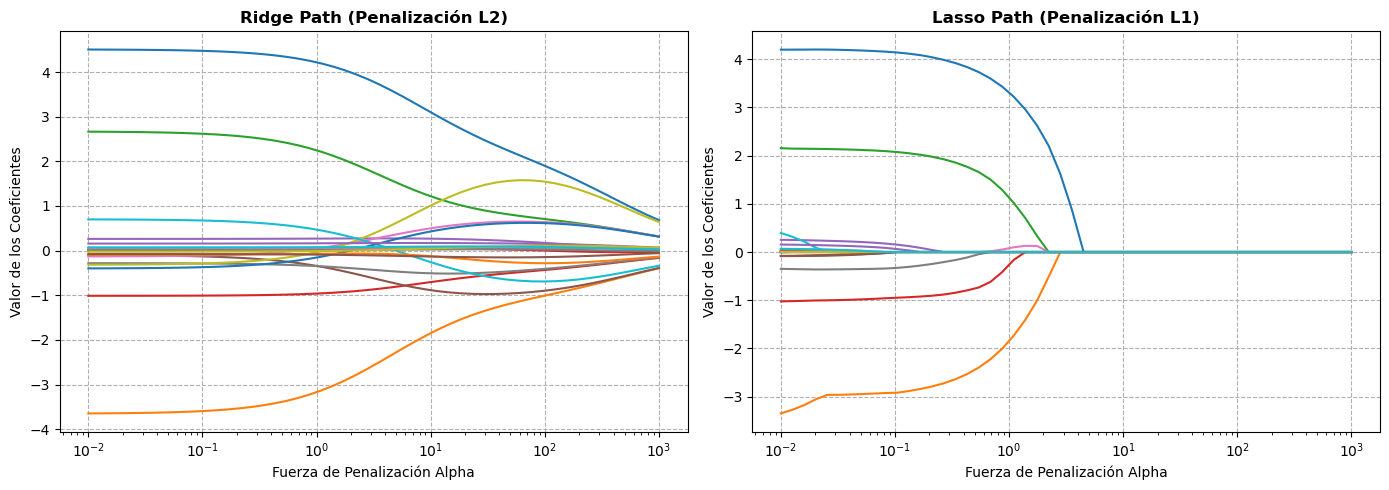

In [3]:
alphas = np.logspace(-2, 3, 50)

coefs_ridge = []
coefs_lasso = []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_scaled, y_train)
    lasso = Lasso(alpha=a, max_iter=2000).fit(X_train_scaled, y_train)
    coefs_ridge.append(ridge.coef_)
    coefs_lasso.append(lasso.coef_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(alphas, coefs_ridge)
ax1.set_xscale('log')
ax1.set_title("Ridge Path (Penalización L2)", fontweight='bold')
ax1.set_xlabel("Fuerza de Penalización Alpha")
ax1.set_ylabel("Valor de los Coeficientes")
ax1.grid(True, linestyle='--')

ax2.plot(alphas, coefs_lasso)
ax2.set_xscale('log')
ax2.set_title("Lasso Path (Penalización L1)", fontweight='bold')
ax2.set_xlabel("Fuerza de Penalización Alpha")
ax2.set_ylabel("Valor de los Coeficientes")
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()


## 3. Optimización con ElasticNetCV

Ajustamos un modelo **ElasticNet** optimizando conjuntamente el nivel de penalización y la proporción entre L1 y L2 mediante validación cruzada interna de 5 pliegues.


In [4]:
l1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99]

elastic_cv = ElasticNetCV(l1_ratio=l1_ratios, cv=5, random_state=42, max_iter=2000)
elastic_cv.fit(X_train_scaled, y_train)

y_pred_en = elastic_cv.predict(X_test_scaled)
rmse_en = np.sqrt(mean_squared_error(y_test, y_pred_en))
r2_en = r2_score(y_test, y_pred_en)

print(f"Parámetros óptimos seleccionados por Cross-Validation:")
print(f"-> Alpha óptimo: {elastic_cv.alpha_:.4f}")
print(f"-> Ratio L1 óptimo: {elastic_cv.l1_ratio_:.2f}")
print(f"-> R2 en conjunto de Test: {r2_en:.3f}")
print(f"-> RMSE en Test: {rmse_en:.3f}")


Parámetros óptimos seleccionados por Cross-Validation:
-> Alpha óptimo: 0.0964
-> Ratio L1 óptimo: 0.99
-> R2 en conjunto de Test: 0.911
-> RMSE en Test: 1.733


### Inspección de Variables Seleccionadas


In [5]:
coef_summary = pd.DataFrame({
    'Variable': [f"X_{i}" for i in range(n_features)],
    'Coeficiente_ElasticNet': elastic_cv.coef_,
    'Beta_Verdadero': beta_real
})

variables_conservadas = coef_summary[coef_summary['Coeficiente_ElasticNet'] != 0]
print(f"Variables seleccionadas (no nulas): {len(variables_conservadas)} de {n_features}")
variables_conservadas


Variables seleccionadas (no nulas): 9 de 20


,Variable,Coeficiente_ElasticNet,Beta_Verdadero
0,X_0,4.141220,4.5
1,X_1,-2.868414,-3.2
2,X_2,2.078593,2.0
3,X_3,-0.948217,-1.5
4,X_4,0.164299,0.0
5,X_5,-0.059611,0.0
7,X_7,-0.337995,0.0
14,X_14,0.072217,0.0
15,X_15,-0.008265,0.0


## 4. Conclusiones

1. **Selección Inteligente**: ElasticNet ha anulado los coeficientes de las variables ruidosas y redundantes, manteniendo con gran precisión las 4 variables que realmente generaban el fenómeno de negocio.
2. **Robustez ante Multicolinealidad**: A diferencia de la regresión por Mínimos Cuadrados Ordinarios (OLS), que colapsaría ante variables redundantes, la regularización garantiza un modelo parsimonioso y estable para producción.
